> **Legacy analysis.** These saved results precede the accounting and validation review. Use `us_snd_model_results.ipynb` for the current 24-month holdout and forecast analysis. This notebook imports `legacy_crude_model` to preserve its original specification.

# PADD Stock-Model Comparison: 10-Fold Time-Series CV

This notebook compares constrained linear regression, random forests, XGBoost, and a neural network on the same PADD crude-oil stock problem. A persistence forecast is included as a sanity-check baseline.

Every candidate is evaluated on identical 10-fold expanding-window splits. Each fold trains only on earlier months and predicts the next block, so later observations never leak into training. Model selection is based only on pooled out-of-fold results.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from xgboost import XGBRegressor

from legacy_crude_model import DEFAULT_EIA_FILE, FEATURE_COLUMNS, PADD_NAMES, load_eia_padd

warnings.filterwarnings('ignore', category=ConvergenceWarning)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
N_SPLITS = 10

## Data and target

The inputs are the same signed physical-balance features used by the production model: current stock, production, negative refinery demand, imports, and negative exports. The target is next-month ending stock. Using identical observations and features makes the comparison about model form rather than data availability.

In [2]:
eia = load_eia_padd(DEFAULT_EIA_FILE)
model_data = (
    eia.dropna(subset=FEATURE_COLUMNS + ['stock_t1_actual_kb'])
       .sort_values(['padd', 'month'])
       .reset_index(drop=True)
)
model_data.groupby(['padd', 'padd_name']).agg(
    start=('month', 'min'), end=('month', 'max'), observations=('month', 'size')
).reset_index()

,padd,padd_name,start,end,observations
0,1,East Coast,2007-01-01,2026-04-01,232
1,2,Midwest,2007-01-01,2026-04-01,232
2,3,Gulf Coast,2007-01-01,2026-04-01,232
3,4,Rocky Mountain,2007-01-01,2026-04-01,232
4,5,West Coast,2007-01-01,2026-04-01,232


## Overfitting controls

Hyperparameters are fixed before examining CV results—there is no repeated tuning against the test folds. Complexity is deliberately conservative:

- **Linear regression:** non-negative coefficients on signed features preserve physical direction.
- **Random forest:** shallow trees, large terminal leaves, and feature subsampling.
- **XGBoost:** depth-two trees, slow learning rate, row/column subsampling, minimum child weight, and strong L1/L2 penalties.
- **Neural network:** one small hidden layer, fold-local standardized inputs and target, weight decay, and early stopping using only data inside each training fold.

The persistence baseline predicts that next month's stock equals current stock. A complex model should beat this simple benchmark out of sample to be useful.

In [3]:
models = {
    'Linear regression': LinearRegression(positive=True),
    'Random forest': RandomForestRegressor(
        n_estimators=300, max_depth=4, min_samples_leaf=8,
        max_features=0.8, n_jobs=-1, random_state=RANDOM_STATE,
    ),
    'XGBoost': XGBRegressor(
        n_estimators=250, max_depth=2, learning_rate=0.03,
        min_child_weight=10, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=1.0, reg_lambda=20.0, objective='reg:squarederror',
        n_jobs=1, random_state=RANDOM_STATE,
    ),
    'Neural network': TransformedTargetRegressor(
        regressor=Pipeline([
            ('scale', StandardScaler()),
            ('mlp', MLPRegressor(
                hidden_layer_sizes=(12,), activation='relu', alpha=0.1,
                learning_rate_init=0.001, max_iter=1500, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=30,
                random_state=RANDOM_STATE,
            )),
        ]),
        transformer=StandardScaler(),
    ),
}
models

{'Linear regression': LinearRegression(positive=True),
 'Random forest': RandomForestRegressor(max_depth=4, max_features=0.8, min_samples_leaf=8,
                       n_estimators=300, n_jobs=-1, random_state=42),
 'XGBoost': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
              max_leaves=None, min_child_weight=10, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=250,
              n_jobs=1, num_parallel_tree=None, ...),
 'Neural network': Tra

## Fit all models on identical expanding windows

Training and test errors are both retained. Test error determines the ranking; the train/test gap is used only as an overfitting diagnostic. The persistence baseline is scored on exactly the same ten test blocks.

In [4]:
def run_time_series_cv(frame, estimators, n_splits=10):
    prediction_rows, fold_rows = [], []
    for padd in sorted(PADD_NAMES):
        regional = frame[frame['padd'] == padd].sort_values('month').reset_index(drop=True)
        X = regional[FEATURE_COLUMNS]
        y = regional['stock_t1_actual_kb']
        splitter = TimeSeriesSplit(n_splits=n_splits)
        for fold, (train_idx, test_idx) in enumerate(splitter.split(X), start=1):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            fold_models = {'Persistence': None, **estimators}
            for name, estimator in fold_models.items():
                if estimator is None:
                    train_pred = X_train['stock_t_kb'].to_numpy()
                    test_pred = X_test['stock_t_kb'].to_numpy()
                else:
                    fitted = clone(estimator)
                    fitted.fit(X_train, y_train)
                    train_pred = fitted.predict(X_train)
                    test_pred = fitted.predict(X_test)

                fold_rows.append({
                    'padd': padd, 'padd_name': PADD_NAMES[padd],
                    'model': name, 'fold': fold,
                    'train_n': len(train_idx), 'test_n': len(test_idx),
                    'train_rmse_kb': mean_squared_error(y_train, train_pred) ** 0.5,
                    'test_rmse_kb': mean_squared_error(y_test, test_pred) ** 0.5,
                })
                for position, prediction in zip(test_idx, test_pred):
                    prediction_rows.append({
                        'padd': padd, 'padd_name': PADD_NAMES[padd],
                        'month': regional.loc[position, 'month'],
                        'model': name, 'fold': fold,
                        'actual_stock_t1_kb': y.iloc[position],
                        'prediction_kb': prediction,
                    })
    return pd.DataFrame(prediction_rows), pd.DataFrame(fold_rows)

predictions, fold_diagnostics = run_time_series_cv(model_data, models, N_SPLITS)
print(f"Generated {len(predictions):,} out-of-fold predictions across {fold_diagnostics['fold'].nunique()} folds.")

Generated 5,250 out-of-fold predictions across 10 folds.


## Out-of-fold results

The first table reports pooled results by model and PADD. `NRMSE` divides RMSE by the PADD's out-of-fold stock standard deviation, allowing regions of different sizes to contribute comparably.

In [5]:
def score_predictions(group):
    actual = group['actual_stock_t1_kb']
    predicted = group['prediction_kb']
    rmse = mean_squared_error(actual, predicted) ** 0.5
    return pd.Series({
        'observations': len(group),
        'mae_kb': mean_absolute_error(actual, predicted),
        'rmse_kb': rmse,
        'r2': r2_score(actual, predicted),
        'nrmse': rmse / actual.std(ddof=0),
    })

padd_metrics = (
    predictions.groupby(['model', 'padd', 'padd_name'], sort=False)
    .apply(score_predictions, include_groups=False)
    .reset_index()
)
padd_metrics.sort_values(['padd', 'rmse_kb']).round(3)

,model,padd,padd_name,observations,mae_kb,rmse_kb,r2,nrmse
0,Persistence,1,East Coast,210.000,"1,046.505","1,378.493",0.820,0.425
1,Linear regression,1,East Coast,210.000,"1,261.137","1,699.819",0.726,0.524
4,Neural network,1,East Coast,210.000,"1,395.920","1,895.786",0.659,0.584
2,Random forest,1,East Coast,210.000,"1,549.947","2,027.201",0.610,0.624
3,XGBoost,1,East Coast,210.000,"1,570.882","2,046.167",0.603,0.630
5,Persistence,2,Midwest,210.000,"4,062.838","5,272.926",0.935,0.255
6,Linear regression,2,Midwest,210.000,"4,460.660","5,743.191",0.923,0.278
9,Neural network,2,Midwest,210.000,"8,776.357","11,652.565",0.682,0.564
7,Random forest,2,Midwest,210.000,"10,226.177","13,232.944",0.590,0.641
8,XGBoost,2,Midwest,210.000,"10,090.290","13,431.868",0.577,0.650


In [6]:
pooled = predictions.groupby('model', sort=False).apply(score_predictions, include_groups=False)
balanced = padd_metrics.groupby('model').agg(
    mean_padd_nrmse=('nrmse', 'mean'),
    median_padd_nrmse=('nrmse', 'median'),
)
ranking = pooled.join(balanced)
ranking['balanced_rank'] = ranking['mean_padd_nrmse'].rank(method='min')
ranking = ranking.sort_values(['balanced_rank', 'rmse_kb'])
ranking.round(3)

,observations,mae_kb,rmse_kb,r2,nrmse,mean_padd_nrmse,median_padd_nrmse,balanced_rank
model,,,,,,,,
Persistence,"1,050.000","3,386.110","5,916.454",1.000,0.019,0.331,0.255,1.000
Linear regression,"1,050.000","3,905.194","7,073.588",1.000,0.022,0.370,0.278,2.000
Random forest,"1,050.000","10,219.799","27,491.314",0.992,0.087,0.578,0.624,3.000
XGBoost,"1,050.000","10,092.706","26,527.874",0.993,0.084,0.581,0.630,4.000
Neural network,"1,050.000","10,049.480","90,579.399",0.918,0.286,0.821,0.584,5.000


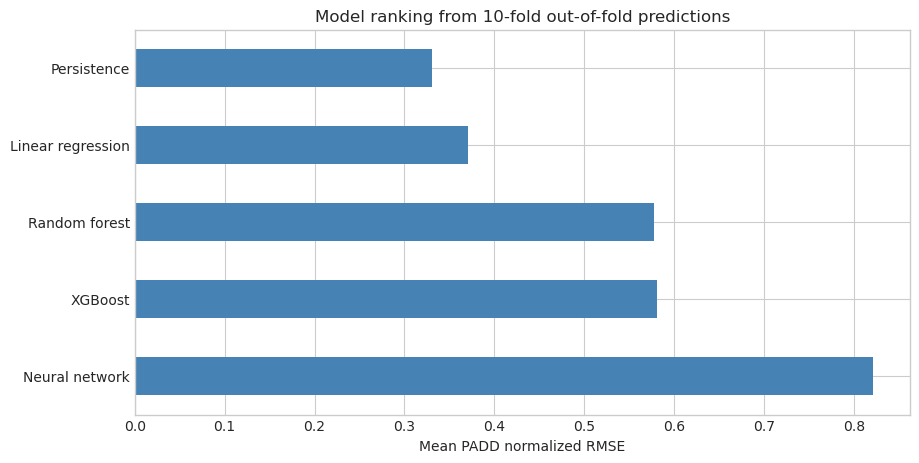

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ranking.sort_values('mean_padd_nrmse')['mean_padd_nrmse'].plot.barh(ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set(title='Model ranking from 10-fold out-of-fold predictions', xlabel='Mean PADD normalized RMSE', ylabel='')
plt.show()

## Overfitting diagnostic

A large test-to-train RMSE ratio indicates that a model fits its training windows much more closely than unseen periods. This ratio is diagnostic—not a selection target—because persistence has no fitted parameters and complex models naturally have lower training error.

In [8]:
overfit_summary = fold_diagnostics.groupby('model').agg(
    mean_train_rmse_kb=('train_rmse_kb', 'mean'),
    mean_test_rmse_kb=('test_rmse_kb', 'mean'),
).sort_values('mean_test_rmse_kb')
overfit_summary['test_to_train_rmse'] = (
    overfit_summary['mean_test_rmse_kb'] / overfit_summary['mean_train_rmse_kb']
)
overfit_summary.round(3)

,mean_train_rmse_kb,mean_test_rmse_kb,test_to_train_rmse
model,,,
Persistence,"3,597.183","4,181.832",1.163
Linear regression,"3,262.328","4,820.093",1.478
XGBoost,"3,270.573","11,650.720",3.562
Random forest,"3,552.676","11,730.534",3.302
Neural network,"3,727.024","19,924.804",5.346


## Best model by PADD and visual inspection

A single overall winner can hide regional differences. The next table identifies the lowest-RMSE model in each PADD, followed by plots of those strictly out-of-fold predictions.

In [9]:
regional_winners = (
    padd_metrics.sort_values(['padd', 'rmse_kb'])
    .groupby('padd', as_index=False).first()
)
regional_winners[['padd', 'padd_name', 'model', 'mae_kb', 'rmse_kb', 'r2', 'nrmse']].round(3)

,padd,padd_name,model,mae_kb,rmse_kb,r2,nrmse
0,1,East Coast,Persistence,"1,046.505","1,378.493",0.820,0.425
1,2,Midwest,Persistence,"4,062.838","5,272.926",0.935,0.255
2,3,Gulf Coast,Persistence,"9,163.090","11,773.133",0.989,0.105
3,4,Rocky Mountain,Persistence,759.290,963.623,0.950,0.224
4,5,West Coast,Random forest,"1,939.314","2,375.778",0.594,0.637


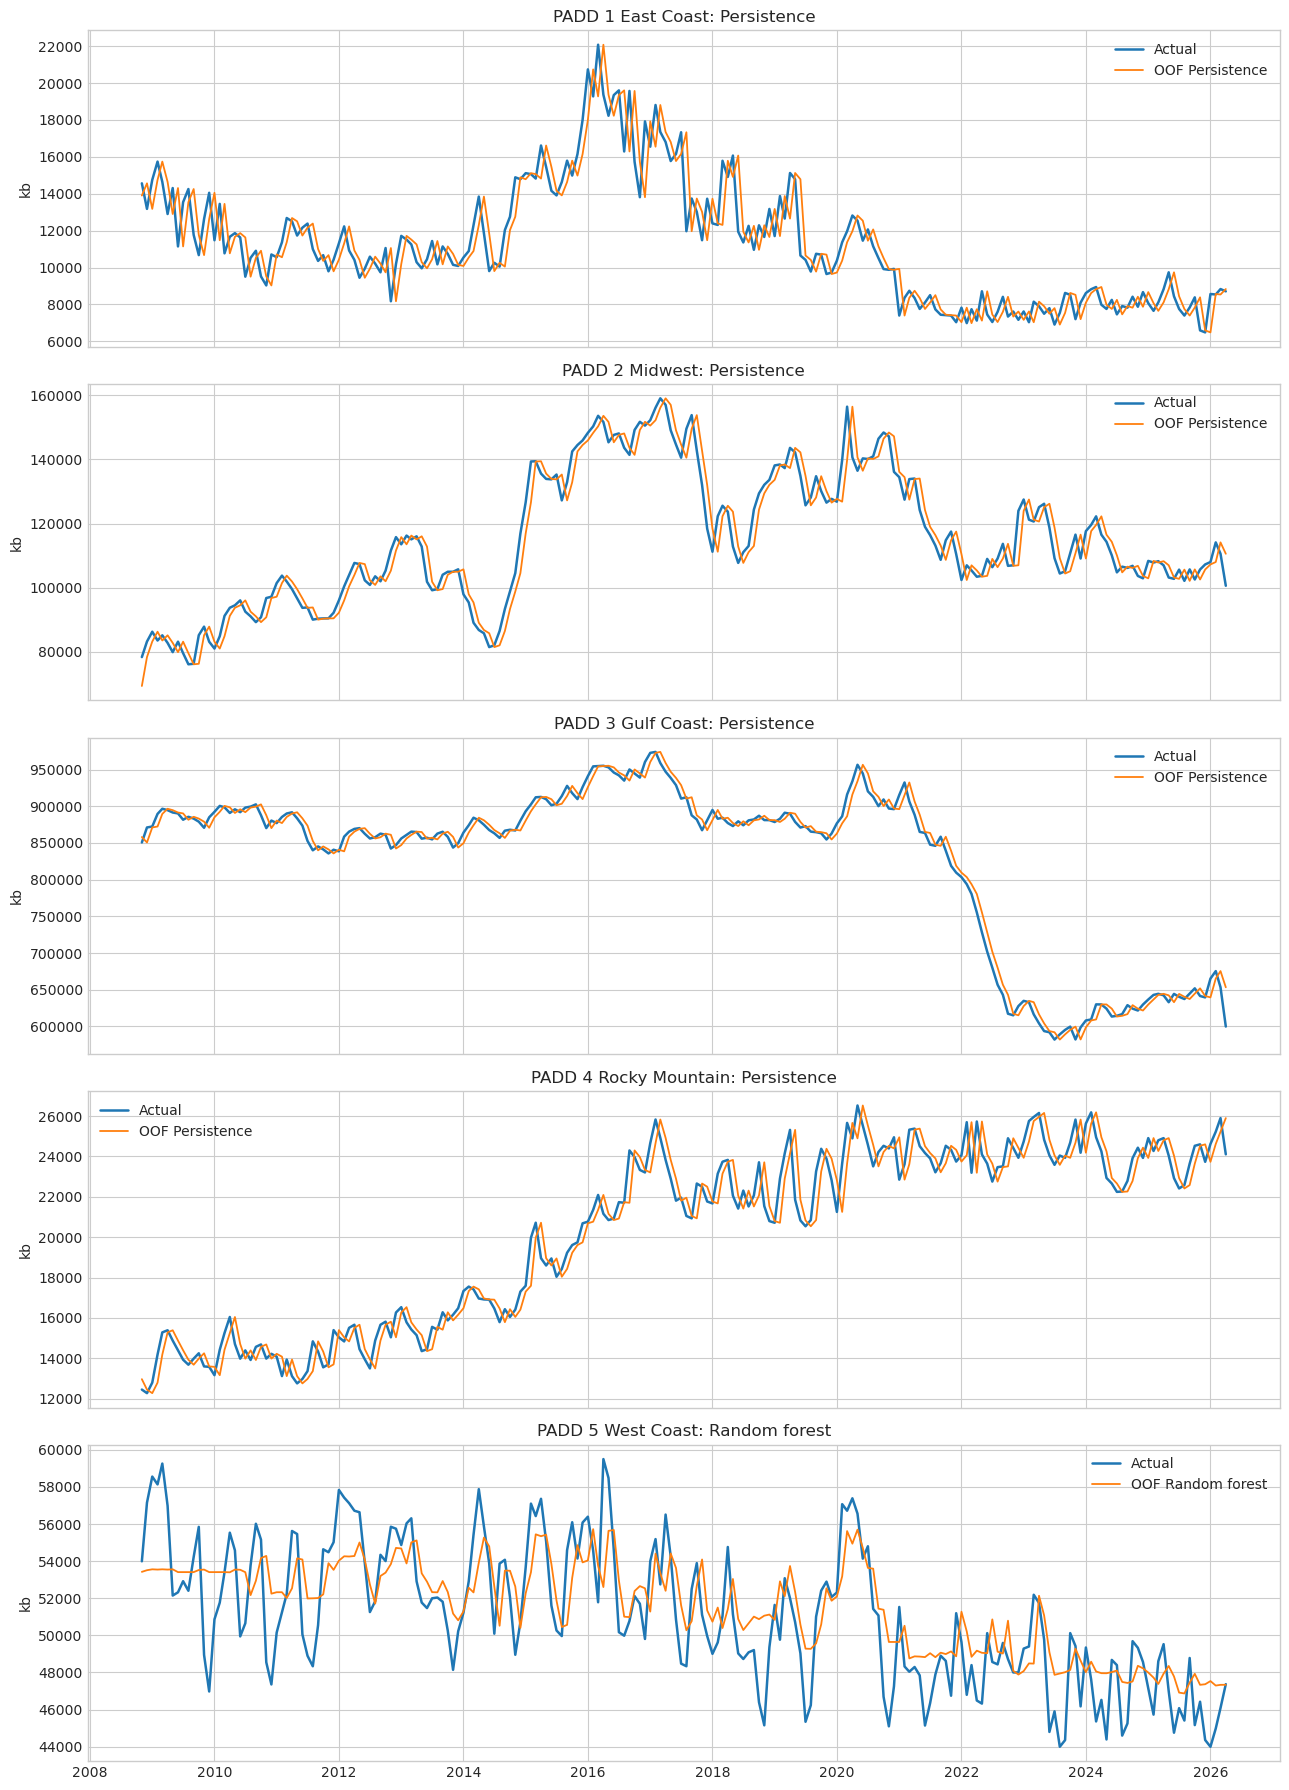

In [10]:
fig, axes = plt.subplots(5, 1, figsize=(13, 18), sharex=True)
for ax, row in zip(axes, regional_winners.itertuples(index=False)):
    view = predictions[(predictions['padd'] == row.padd) & (predictions['model'] == row.model)]
    ax.plot(view['month'], view['actual_stock_t1_kb'], label='Actual', lw=1.8)
    ax.plot(view['month'], view['prediction_kb'], label=f'OOF {row.model}', lw=1.3)
    ax.set_title(f'PADD {row.padd} {row.padd_name}: {row.model}')
    ax.set_ylabel('kb')
    ax.legend()
fig.tight_layout()
plt.show()

## Selection

The recommended overall model is selected by the lowest mean PADD normalized RMSE. This gives every PADD equal weight and avoids selecting a model merely because it performs well on the much larger Gulf Coast stock series. The conclusion below is generated from the executed results.

In [11]:
winner = ranking.index[0]
fitted_ranking = ranking.drop(index='Persistence')
fitted_winner = fitted_ranking.index[0]
winner_row = ranking.loc[winner]
fitted_row = fitted_ranking.loc[fitted_winner]
print(f'Best overall benchmark or model: {winner}')
print(f'Best fitted model: {fitted_winner}')
print(f"Best fitted mean PADD normalized RMSE: {fitted_row['mean_padd_nrmse']:.3f}")
print(f"Best fitted pooled out-of-fold MAE: {fitted_row['mae_kb']:,.0f} kb")
print(f"Best fitted pooled out-of-fold RMSE: {fitted_row['rmse_kb']:,.0f} kb")
print(f"Best fitted pooled out-of-fold R²: {fitted_row['r2']:.3f}")
if winner == 'Persistence':
    print('Caution: no fitted model beats the persistence baseline overall; replacing it would not be justified by CV.')

Best overall benchmark or model: Persistence
Best fitted model: Linear regression
Best fitted mean PADD normalized RMSE: 0.370
Best fitted pooled out-of-fold MAE: 3,905 kb
Best fitted pooled out-of-fold RMSE: 7,074 kb
Best fitted pooled out-of-fold R²: 1.000
Caution: no fitted model beats the persistence baseline overall; replacing it would not be justified by CV.


In [12]:
output_dir = Path('model_comparison_output')
output_dir.mkdir(exist_ok=True)
predictions.to_csv(output_dir / 'out_of_fold_predictions.csv', index=False)
fold_diagnostics.to_csv(output_dir / 'fold_diagnostics.csv', index=False)
padd_metrics.to_csv(output_dir / 'padd_model_metrics.csv', index=False)
ranking.to_csv(output_dir / 'overall_model_ranking.csv')
regional_winners.to_csv(output_dir / 'regional_winners.csv', index=False)
print(f'Comparison outputs written to {output_dir.resolve()}')

Comparison outputs written to /home/calvin/commodities/oil/us_snd_crude/model_comparison_output


## Detailed notes on every model and the comparison

### How to read the ranking

All metrics come from the same 1,050 out-of-fold predictions: 210 months for each of five PADDs. Mean PADD NRMSE is the primary ranking statistic because it gives each region equal weight; pooled RMSE is dominated by the much larger Gulf Coast inventory series. R² is useful within a PADD but rounds close to one in the pooled table because between-region stock-level variation is enormous. It should not be used alone to choose the model.

### Persistence baseline

Persistence forecasts `Stock_t+1 = Stock_t`. It has no fitted parameters, mean PADD NRMSE of 0.331, pooled MAE of 3,386 kb, and pooled RMSE of 5,916 kb. It wins PADDs 1–4 and loses only narrowly to random forest in PADD 5. This is a demanding benchmark because monthly stock levels are highly persistent and the reported PADD flow identity omits transfers and adjustments. Any production model should beat persistence out of fold, not merely explain in-sample levels.

### Constrained linear regression

Linear regression is the best fitted model, with mean PADD NRMSE of 0.370, pooled MAE of 3,905 kb, and pooled RMSE of 7,074 kb. It is about 12% worse than persistence on the balanced metric, but materially better than all nonlinear fitted alternatives. Its test-to-train RMSE ratio is 1.48: some generalization loss is present, but it is far smaller than for the tree and neural models. The model benefits from a strong current-stock term and physically signed flow effects. It remains interpretable and extrapolates beyond the historical feature range, which is valuable for scenario analysis.

Regionally, linear regression is closest to persistence in PADDs 2 and 5. Its weakest relative result is PADD 1, where RMSE is 1,700 kb versus 1,378 kb for persistence. The comparison indicates that adding the reported flow variables to current stocks does not reliably improve a one-month forecast in most regions under this level specification.

### Random forest

The random forest uses 300 shallow depth-four trees, minimum leaf size eight, and feature subsampling. Despite these controls, mean PADD NRMSE rises to 0.578 and pooled RMSE to 27,491 kb. Its average test-to-train RMSE ratio is 3.30, showing that the historical partitions learned inside training windows do not transfer well to later regimes. Trees also cannot extrapolate smoothly beyond training ranges, a serious limitation when stock and export levels trend over time.

PADD 5 is the exception: random-forest RMSE is 2,376 kb, slightly better than persistence at 2,405 kb and linear regression at 2,435 kb. That regional gain is too small to offset large errors elsewhere, particularly the 59,918 kb Gulf Coast RMSE. A region-specific forest could be investigated for PADD 5, but the current evidence does not support it as the national default.

### XGBoost

XGBoost is deliberately regularized with depth-two trees, a 0.03 learning rate, row and feature subsampling, minimum child weight, and strong L1/L2 penalties. Its pooled RMSE of 26,528 kb is slightly lower than random forest, but mean PADD NRMSE of 0.581 is slightly worse, placing it fourth on the balanced ranking. The 3.56 test-to-train RMSE ratio is the largest among the tree models.

XGBoost and random forest have very similar regional error patterns, suggesting that the main problem is not the exact ensemble algorithm. Both fit nonlinear thresholds in past regimes that do not extrapolate into later expanding-window test periods. Stronger tuning against the same outer folds would risk selection overfitting and is not justified by these results.

### Neural network

The neural network has one 12-unit hidden layer, standardized inputs and targets, weight decay, and early stopping within each training fold. Even with those safeguards, it is the least stable model: mean PADD NRMSE is 0.821, pooled RMSE is 90,579 kb, and the test-to-train RMSE ratio is 5.35. PADD 3 is the main failure, with negative R² and RMSE above 202,000 kb, indicating catastrophic sensitivity to distribution shifts in the largest region.

The network's PADD 1, 2, 4, and 5 errors are less extreme but still do not beat persistence. With only roughly two hundred monthly observations per region, the sample is too small for even a compact neural model to learn stable nonlinear structure. Increasing network size or training duration would increase overfitting risk rather than address the regime-shift problem.

### Final comparison and decision

Persistence is the strongest pure forecasting rule overall. Among models that explicitly use the supply-and-demand variables, constrained linear regression is the clear winner because it has the lowest balanced and pooled errors, the smallest generalization gap, physical sign control, and transparent coefficients. Random forest offers a small PADD 5 gain but performs poorly elsewhere; XGBoost adds no reliable advantage over random forest; and the neural network is unsuitable for this sample size. The evidence supports keeping linear regression for an interpretable SnD model while always reporting persistence beside it as the forecast benchmark.